d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

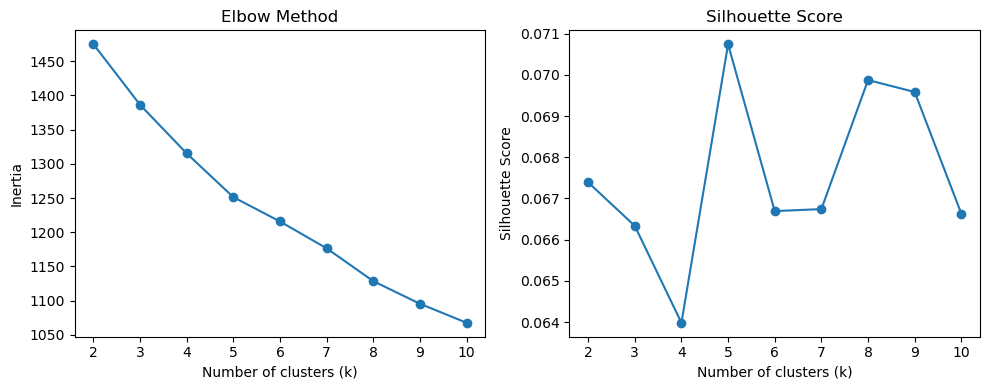

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load the dataset
df_updated = pd.read_csv("database/Cruise_Preferences_Dataset.csv")

# Step 1: Standardize all numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_updated)
# X_scaled is now a NumPy array with mean = 0 and std = 1 for each feature

# Step 2: Use Elbow Method and Silhouette Score to choose optimal number of clusters
inertia = []  # Sum of squared distances to cluster centers
silhouette_scores = []  # Average silhouette scores for each k
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Method (inertia vs. k) and Silhouette Score
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


In [6]:

# Step 3: Choose optimal k based on silhouette score and fit KMeans
optimal_k = K_range[silhouette_scores.index(max(silhouette_scores))]
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to original DataFrame
df_with_clusters = df_updated.copy()
df_with_clusters['cluster'] = cluster_labels

# Get cluster centroids in original feature space (by inverse transforming scaled centroids)
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns=df_updated.columns)

# Save cluster centroids to a CSV file
centroids_df.to_csv("database/k mean result.csv", index=False)
centroids_df

d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,destination,cabin_type,activity_interests_cultural,activity_interests_nature_outdoors,activity_interests_entertainment,activity_interests_shopping,activity_interests_recreation,activity_interests_nightlife,hotel_preferences,food_preferences_asian,food_preferences_european,food_preferences_american_latin,food_preferences_middle_eastern,food_preferences_african,food_preferences_caribbean,food_preferences_local_cuisine
0,3.150000,3.400000,0.800000,0.800000,0.550000,0.550000,0.250000,0.800000,1.500000,0.150000,0.700000,0.700000,0.450000,0.300000,0.800000,0.700000
1,4.000000,2.263158,0.736842,0.263158,0.421053,0.578947,0.105263,0.210526,2.210526,0.736842,0.157895,0.421053,0.368421,0.631579,0.368421,0.578947
2,2.565217,2.913043,0.173913,0.782609,0.304348,0.217391,0.652174,0.565217,2.391304,0.608696,0.217391,0.565217,0.782609,0.565217,0.347826,0.304348
3,2.944444,1.944444,0.777778,0.166667,0.333333,0.833333,0.944444,0.888889,1.444444,0.666667,0.611111,0.166667,0.500000,0.555556,0.500000,0.722222
4,1.700000,2.650000,0.300000,0.050000,0.750000,0.200000,0.300000,0.250000,2.200000,0.550000,1.000000,0.400000,0.350000,0.400000,0.450000,0.550000


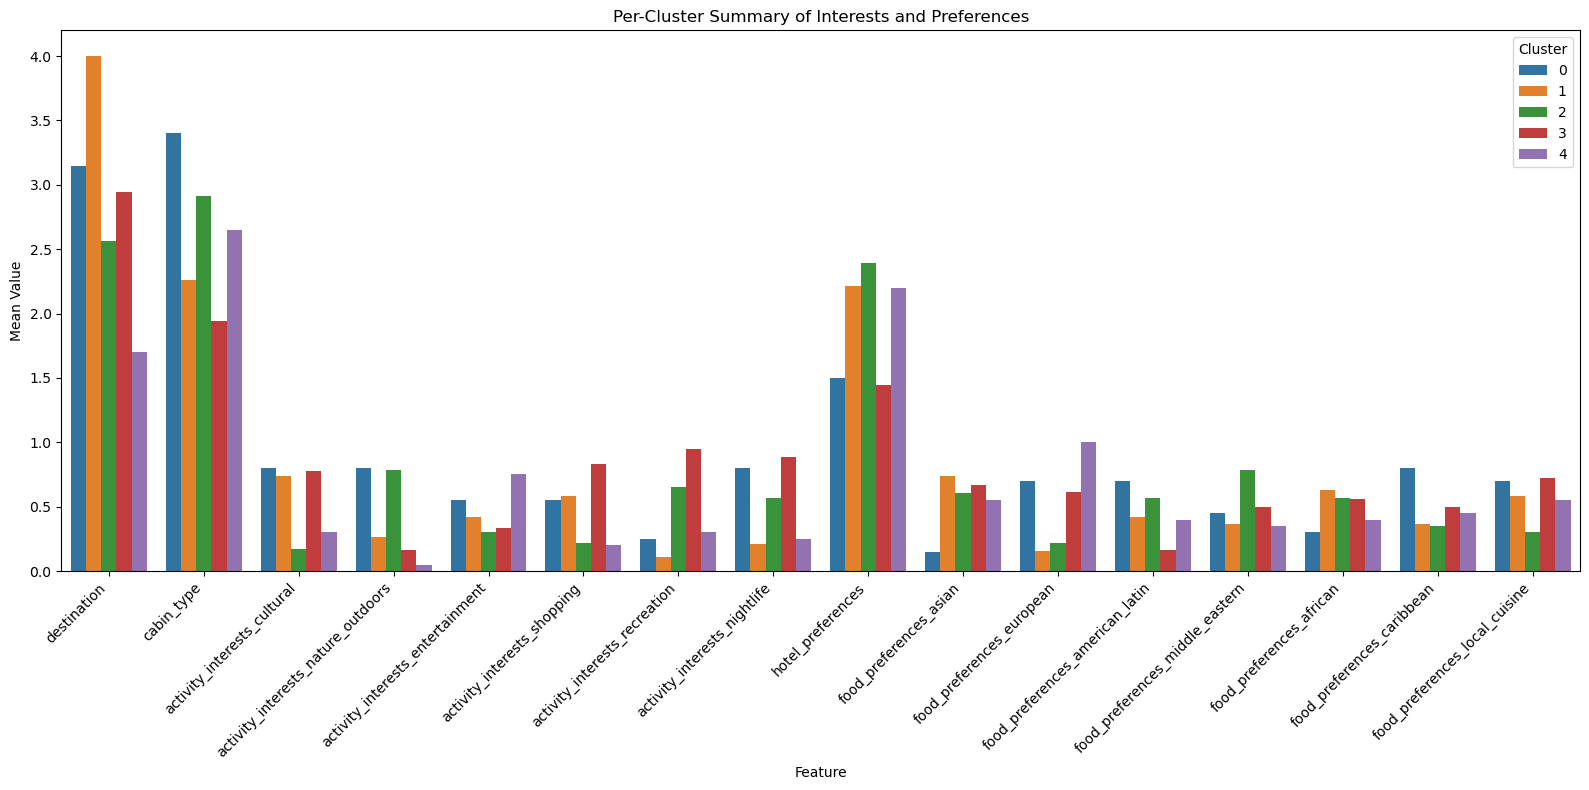

In [10]:
# Compute mean values of each feature for each cluster
cluster_summary = df_with_clusters.groupby('cluster').mean(numeric_only=True)

# Reshape data for plotting
melted_summary = cluster_summary.reset_index().melt(id_vars='cluster', 
                                                    var_name='Feature', 
                                                    value_name='Mean Value')

# Convert cluster column to string to avoid issues in legend labeling
melted_summary['cluster'] = melted_summary['cluster'].astype(str)

# Create barplot using seaborn with rotated labels
plt.figure(figsize=(16, 8))
sns.barplot(data=melted_summary, x='Feature', y='Mean Value', hue='cluster')

plt.title('Per-Cluster Summary of Interests and Preferences')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()





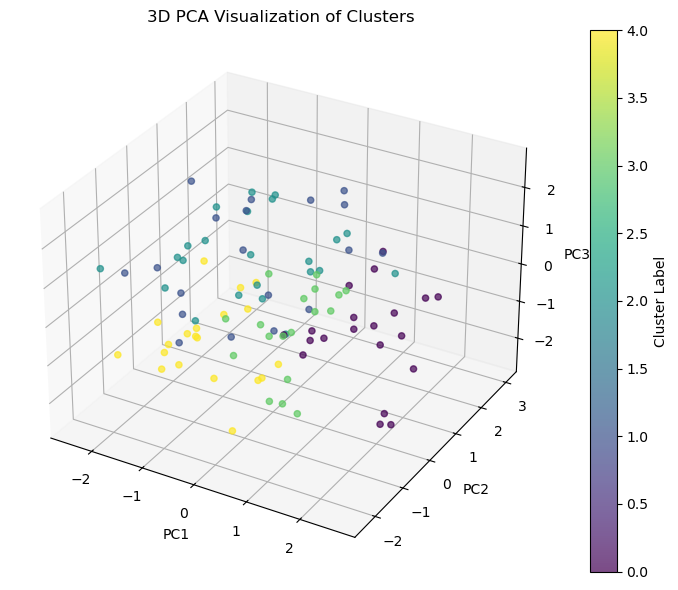

In [11]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D 

# Reduce the dimension of the standardized data to 3 dimensions
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                     c=cluster_labels, cmap='viridis', alpha=0.7)


ax.set_title('3D PCA Visualization of Clusters')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')


plt.colorbar(scatter, ax=ax, label='Cluster Label')

plt.tight_layout()
plt.show()
